# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

Loaded 30 data points
slope m ± 𝝈_m = 2.02 ± 0.5814, y-intercept b ± 𝝈_b = 31.23 ± 3.6707, and chi squared is 22.721790910144666


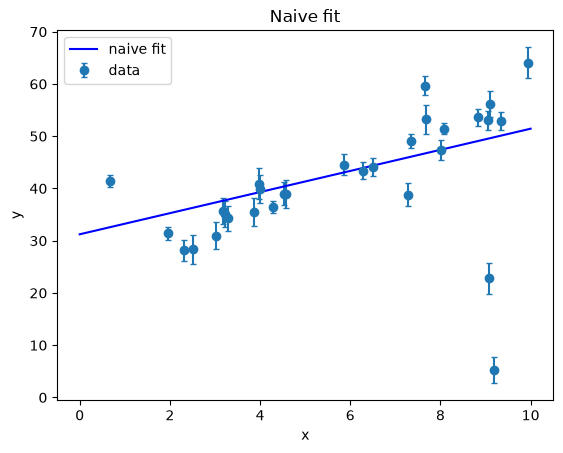

In [63]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt(f'data/saumyap2.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']
n = len(x)
print(f"Loaded {n} data points")

naive_fit = np.polyfit(x, y, 1, w=1/sigma_y, cov=True)
m, b = naive_fit[0]
sigma_m, sigma_b = np.sqrt(np.diag(naive_fit[1]))

resid = y - np.polyval(naive_fit[0], x)
chi_2 = np.sum(resid**2/sigma_y**2) / (n-2)

print( f'slope m ± 𝝈_m = {m:.2f} ± {sigma_m:.4f}, y-intercept b ± 𝝈_b = {b:.2f} ± {sigma_b:.4f}, and chi squared is {chi_2}')

xx = np.linspace(0,10,200)
plt.errorbar(x,y,yerr = sigma_y, fmt='o', capsize=2, label='data')
plt.plot(xx, np.polyval(naive_fit[0], xx), 'b-', label='naive fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive fit')
plt.show()

**ANSWER (a few sentences):**

The high reduced chi squared value is telling us that the model is not a good fit for the data because there are many points that don't follow the model's trend. The data is scattered much more than the error bars predict. I would not trust these error bars. 

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

3-Sigma clipping fit: slope m ± 𝝈_m = 3.46 ± 0.1623, y-intercept b ± 𝝈_b = 22.93 ± 1.0399, and chi squared is 1.143386551811367


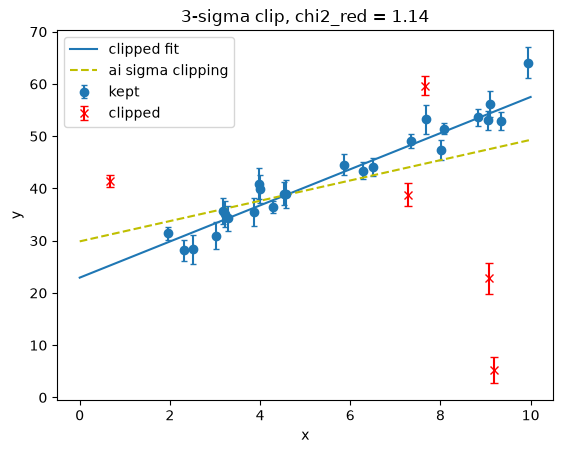

In [69]:
# Part 2: your work here
def sigma_clip_fit(x, y, sigma, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p, cov = np.polyfit(x[mask], y[mask], 1, w=1/sigma[mask], cov=True)
        resid = (y - np.polyval(p, x)) / sigma
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, cov, mask

p_clip, cov, mask = sigma_clip_fit(x, y, sigma_y, k=3.0)
m_clip, b_clip = p_clip
sigma_m_clip, sigma_b_clip = np.sqrt(np.diag(cov))
resid = y[mask] - np.polyval(p_clip, x[mask])
chi_2_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)
print( f'3-Sigma clipping fit: slope m ± 𝝈_m = {m_clip:.2f} ± {sigma_m_clip:.4f}, y-intercept b ± 𝝈_b = {b_clip:.2f} ± {sigma_b_clip:.4f}, and chi squared is {chi_2_clip}')

#ai_solution
coeffs, cov_ai = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
ai_mask = np.abs(residuals) < threshold
m_err, b_err = np.sqrt(np.diag(cov_ai))


plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=2, label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label='clipped fit')
plt.plot(xx, np.polyval(coeffs, xx), 'y--', label='ai sigma clipping')

plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'3-sigma clip, chi2_red = {chi_2_clip:.2f}')
plt.show()

mixture fit:  slope m ± 𝝈_m = 3.45 ± 0.8598, y-intercept b ± 𝝈_b = 22.97 ± 2.0996, outlier fraction Pb=0.21


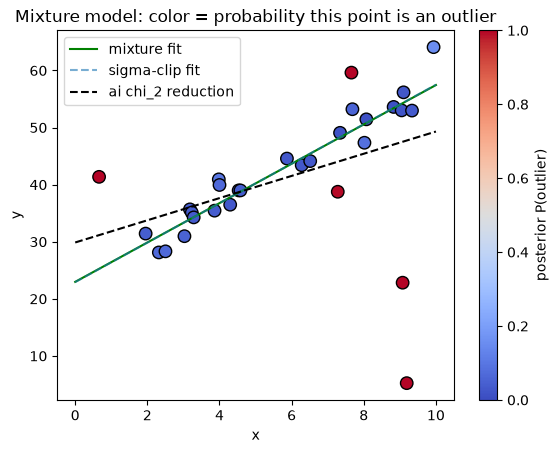

point-by-point P(outlier):
  point 0: P(outlier)=1.00
  point 27: P(outlier)=1.00
  point 25: P(outlier)=1.00
  point 19: P(outlier)=1.00
  point 17: P(outlier)=1.00
  point 29: P(outlier)=0.16


In [74]:
# 2.

from scipy.optimize import minimize
from scipy.stats import norm

Yb_fixed = np.median(y)
def neg_log_likelihood(theta, x, y, Yb, sigma):
    m, b, Pb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma_y)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma_y**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

# start from the sigma-clip fit
theta0 = [p_clip[0], p_clip[1], 0.2, np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, Yb_fixed, sigma_y),method='L-BFGS-B')
m_mix, b_mix, Pb_mix, lnVb_mix = result.x
n_params = len(result.x)
cov = result.hess_inv @ np.eye(n_params) 
sigma_m_mix = np.sqrt(cov[0, 0])
sigma_b_mix = np.sqrt(cov[1, 1])
print(f"mixture fit:  slope m ± 𝝈_m = {m_mix:.2f} ± {sigma_m_mix:.4f}, y-intercept b ± 𝝈_b = {b_mix:.2f} ± {sigma_b_mix:.4f}, outlier fraction Pb={Pb_mix:.2f}")

# per-point posterior probability of belonging to the "bad" population
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma_y)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad_l / (good_l + bad_l)



# ai
chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof

scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale


plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='sigma-clip fit')
plt.plot(xx, m_fit * xx + b_fit, 'k--', label='ai chi_2 reduction')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Mixture model: color = probability this point is an outlier')
plt.show()

print("point-by-point P(outlier):")
for i in np.argsort(-p_bad)[:6]:
    print(f"  point {i}: P(outlier)={p_bad[i]:.2f}")

**FINAL ANSWER:** $m = $3.45 $\pm$ 0.8598 , $b = $ 22.97 $\pm$ 2.0996 , outlier fraction $\approx$ 0.21

**Justification and uncertainty method (a short paragraph):**

*your answer goes here*
The final answer is that I would commit to the mixture model. Both methods agree closely in their estimates (m: 3.46 vs 3.45, b:22.93 vs 22.97) which is strong evidence backing the mixture model's fit. But the mixture model is more honest in its approach. Sigma-clipping has a level overconfidence to it since it completely removes outliers when calculating the best fit. However, the mixture model assigns each point a probability of being good and bad, therefore using all the data , including the outliers, with this weighting. This is also why its error bars are larger than the sigma-clipping model.  The near-unity reduced chi-square of the clipped fit corroborates that the kept points are consistent with their error bars, but the mixture remains the principled choice. I modeled each point as drawn from a broad outlier population centered around the median (more robust than the mean) with free width $V_b$. Uncertainties come from the inverse Hessian of the negative log-likelihood at the minimum.


## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1:* It didn't use weights on the data points. It called np.polyfit(x, y, 1, cov=True) with no weights. Each point, including the contaminants, were weighted equally. This initial fit differs from my weighted naive fit (m = 1.9 vs 2.02)  This is clearly not close to the more accurate initial fit, which causes greater variation as it continues to modify its fit.

*Flaw 2:* As I just mentioned, as it continues to modify its fit using sigma clipping, it only uses a single, unweighted pass. This leads to only 1 outlier being removed compared to the 4 that are removed when I did a sigma-clipping with a max iteration of 10. This mistake is clear in its slope estimate deviance (2.68 v 3.46). As I said, the correct treatment when doing a sigma clipping is to run through multiple iterations using a weighted initial fit until all the outliers are removed. However, an even more accurate and honest fit is to use a mixture model, including all data points with good and bad probabilities.

*Flaw 3:* It rescales the uncertainties to force chi squared =1, masking the problem instead of solving it. It multiplies ann sigma_y by the chi in order to do so. This is circular reasoning because it changes the measurements to present a good fit, not the other way around. As you can see in my mixture model plot, the black dashed line represents this reduced chi_2 fit which clearly deviates from the trend seen by the proper data (m = 2.68 vs 3.45). The correct treatment would be to edit your model in order to achieve a better chi_2, rather than rescaling to make it seem presentable.

AI fits plotted with mine in Part 2 are used as my demonstrations

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

EcoGPT Prompts:

How do I get uncertainties from np.polyfit()?

What does minimize() do?

How can I get uncertainties when using minimize()?

**VERIFICATION PLAN:**

1. the 2 methods agree in their estimates. Failed if they were widely different.
2. the chi_2 is close to 1. Failed if chi_2 is a large number.
3. Looking at the mixture model to see if the probabilities make sense. Failed if the ones farther from the mean or median weren't redder than the closer ones.
4. Outlier fraction makes sense. Failed if the fraction was high or really low.
5. Mixture model uncertainties are higher than sigma-clipping which makes sense. Failed if The were similar or if the opposite were true.
